In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def show_img(titulo, image):
    cv2.imshow(titulo, image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

In [5]:
#processo padrão de ler a imagem e criar um canva vazio
img = cv2.imread('../assets/fotos/cats.jpg')
#img = cv2.imread('../assets/fotos/cat.jpg')
show_img('gatinhos da asimov', img)

blank = np.zeros(img.shape[:2], dtype='uint8')

In [7]:
#primeiro, vamos calcular o historgrama da imagem em cinza

#converter a imagem para P&B
cinza = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
show_img('gatitos da asimov', cinza)

In [8]:
#Histograma de P&B
#cv2,calcHist(imagem, canais_de_cor(RGB, BGR), mascara, tamanho_do_hist, ranges)
cinza_hist = cv2.calcHist([cinza], [0], None, [256], [0,256])

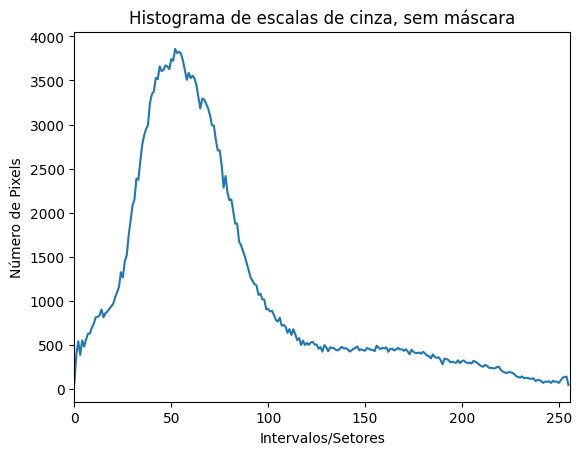

In [9]:
plt.figure()
plt.title('Histograma de escalas de cinza, sem máscara')
plt.xlabel('Intervalos/Setores')
plt.ylabel('Número de Pixels')
plt.plot(cinza_hist)
plt.xlim([0,256])
plt.show()

Ao plotar essa figura, podemos observar que temos um grande concentração de valores proximos de zero, afinal estamos obsevando uma imagem P&B, onde o 0 representa valores completamente escuros e 255 valores brancos

Neste caso, como voltamos a imagem original( não a preta e branco), podemos analisar canais diferentes alem do preto ao branco, os canais RGB( lidos pelo cv2 omo BGR). Para isso, iteraremos pelos canais, traçando novas linhas em nosso gráfico.

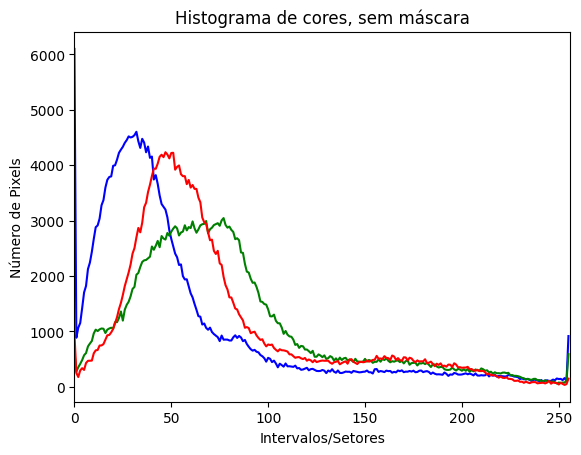

In [10]:
plt.figure()
plt.title('Histograma de cores, sem máscara')
plt.xlabel('Intervalos/Setores')
plt.ylabel('Número de Pixels')
colors = ('b', 'g', 'r')
for channel, cor in enumerate(colors):
    hist = cv2.calcHist([img], [channel], None, [256], [0,256])
    plt.plot(hist, color=cor)
    plt.xlim([0,256])
plt.show()

Se quisermos, podemos analisar trehos especifios de cada imagem, palicando apenas uma mascara na imagem e traçando o histograma ( para plotar é o mesmo codigo, porem como a adição da máscara)

In [13]:
mask = cv2.circle(blank, (img.shape[1]//2, img.shape[0]//2), 100, 255, -1)
show_img('Mascara', mask)

masked = cv2.bitwise_and(img, img, mask=mask)
show_img('Mascara aplicada', masked)

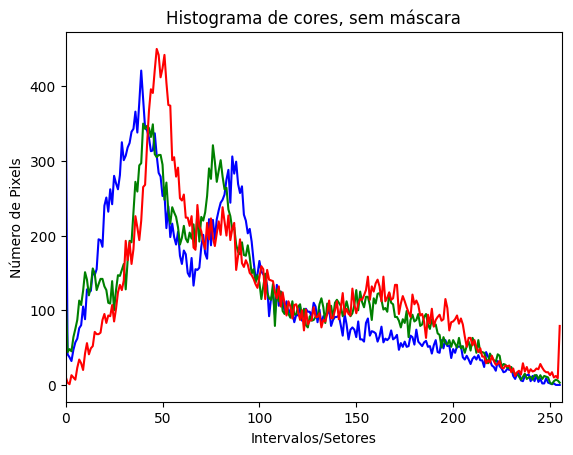

In [15]:
plt.figure()
plt.title('Histograma de cores, sem máscara')
plt.xlabel('Intervalos/Setores')
plt.ylabel('Número de Pixels')
colors = ('b', 'g', 'r')
for channel, cor in enumerate(colors):
    hist = cv2.calcHist([img], [channel], mask, [256], [0,256])
    plt.plot(hist, color=cor)
    plt.xlim([0,256])
plt.show()